# Experiment 108 -- Simulation of the physics experiment

This was made by Diana Shendryk, 108023104727 and Sandra Kruger, 108018216869.

This code is based on the `labcourse.jl` Pluto notebook provided for the 108 lab course.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120

## Exercise 1: Methods of solving ODEs

### Simulation parameters

We consider a charged particle (electron charge, $q=-e$) in a constant field
$\vec E = E\,\vec e_x$, $\vec B = B\,\vec e_z$. 

The momentum $p_{x0}=0.01\,\text{GeV}/c$ is chosen well below the
particle mass $m=1\,\text{GeV}/c^2$ so that $v \ll c$ and the non-relativistic
equation of motion used below ($v = p/m$) stays valid ($v_0/c = p_{x0}/m \approx 0.01$).

(Pluto's sliders are replaced by plain Python variables \-- we could't find similar UI in a Jupyter notebook, so the parameters are simply set by hand in the cell below and the notebook is re-run after changing them).

We start with setting the field, charge, mass and initial conditions as plain variables.

In [3]:
q_e = -1.0 #in units of the elementary charge
m = 1.0 #GeV/c^2

Ex, Ey, Ez = 3.0e5, 0.0, 0.0 #V/m 

Bx, By, Bz = 0.0, 0.0, 1.0 #T 

t0 = 0.0 #s
x0, y0, z0 = 0.0, 0.0, 0.0 #m
px0, py0, pz0 = 0.01, 0.0, 0.0 #GeV/c

tmax = 100.0e-9 #s
dt = 1e-9 #s

Define the physical constants used to convert between GeV/c, GeV and SI units.

In [4]:
# Physical constants
GeV_to_J = 1.60218e-10 #J/GeV
c = 299792458.0 #m/s
e = 1.60217663e-19 #elementary chare

Define the Lorentz force RHS and it's components.

In [5]:
def eom(r, par):
    
    t, x, y, z, En, px, py, pz = r
    q, m_GeV, E_field, B_field = par

    m_SI = m_GeV * GeV_to_J / c**2
    px_SI = px * GeV_to_J / c
    py_SI = py * GeV_to_J / c
    pz_SI = pz * GeV_to_J / c

    vx = px_SI / m_SI
    vy = py_SI / m_SI
    vz = pz_SI / m_SI

    Ex, Ey, Ez = E_field
    Bx, By, Bz = B_field

    Fx = q * (Ex + vy * Bz - vz * By)
    Fy = q * (Ey + vz * Bx - vx * Bz)
    Fz = q * (Ez + vx * By - vy * Bx)

    dpx = Fx / (GeV_to_J / c)
    dpy = Fy / (GeV_to_J / c)
    dpz = Fz / (GeV_to_J / c)

    return np.array([1.0, vx, vy, vz, 0.0, dpx, dpy, dpz])

Next three window are implementations of the Euler, redictor-corrector and RK4 integrator functions.

In [6]:
def euler(f, r0, par, tmax, dt):
    ts = np.arange(r0[0] + dt, tmax + dt / 2, dt)
    r = np.array(r0, dtype=float)
    rs = [r.copy()]

    for t in ts:
        r = r + dt * f(r, par)
        rs.append(r.copy())

    return rs

In [7]:
def predictor_corrector(f, r0, par, tmax, dt):
    ts = np.arange(r0[0] + dt, tmax + dt / 2, dt)
    r = np.array(r0, dtype=float)
    rs = [r.copy()]

    for t in ts:
        r_pred = r + dt * f(r, par)
        r = r + dt / 2 * (f(r, par) + f(r_pred, par))
        rs.append(r.copy())

    return rs

In [8]:
def runge_kutta_4(f, r0, par, tmax, dt):
    ts = np.arange(r0[0] + dt, tmax + dt / 2, dt)
    r = np.array(r0, dtype=float)
    rs = [r.copy()]

    for t in ts:
        k1 = dt * f(r, par)
        k2 = dt * f(r + 0.5 * k1, par)
        k3 = dt * f(r + 0.5 * k2, par)
        k4 = dt * f(r + k3, par)

        r = r + (k1 + 2 * k2 + 2 * k3 + k4) / 6
        rs.append(r.copy())

    return rs

Assemble field parameters and the initial state vector.

In [9]:
E_field = (Ex, Ey, Ez)
B_field = (Bx, By, Bz)
q = q_e * e
par = (q, m, E_field, B_field)

E0 = np.sqrt(px0**2 + py0**2 + pz0**2 + m**2) # natural units, c = 1
r0 = np.array([t0, x0, y0, z0, E0, px0, py0, pz0])

Propagate the trajectory with all three integrators.

In [10]:
rs_rk4 = runge_kutta_4(eom, r0, par, tmax, dt)
rs_euler = euler(eom, r0, par, tmax, dt)
rs_pc = predictor_corrector(eom, r0, par, tmax, dt)

Extract the time array from the RK4 result.

In [11]:
ts = np.array([r[0] for r in rs_rk4])
ts

array([0.0e+00, 1.0e-09, 2.0e-09, 3.0e-09, 4.0e-09, 5.0e-09, 6.0e-09,
       7.0e-09, 8.0e-09, 9.0e-09, 1.0e-08, 1.1e-08, 1.2e-08, 1.3e-08,
       1.4e-08, 1.5e-08, 1.6e-08, 1.7e-08, 1.8e-08, 1.9e-08, 2.0e-08,
       2.1e-08, 2.2e-08, 2.3e-08, 2.4e-08, 2.5e-08, 2.6e-08, 2.7e-08,
       2.8e-08, 2.9e-08, 3.0e-08, 3.1e-08, 3.2e-08, 3.3e-08, 3.4e-08,
       3.5e-08, 3.6e-08, 3.7e-08, 3.8e-08, 3.9e-08, 4.0e-08, 4.1e-08,
       4.2e-08, 4.3e-08, 4.4e-08, 4.5e-08, 4.6e-08, 4.7e-08, 4.8e-08,
       4.9e-08, 5.0e-08, 5.1e-08, 5.2e-08, 5.3e-08, 5.4e-08, 5.5e-08,
       5.6e-08, 5.7e-08, 5.8e-08, 5.9e-08, 6.0e-08, 6.1e-08, 6.2e-08,
       6.3e-08, 6.4e-08, 6.5e-08, 6.6e-08, 6.7e-08, 6.8e-08, 6.9e-08,
       7.0e-08, 7.1e-08, 7.2e-08, 7.3e-08, 7.4e-08, 7.5e-08, 7.6e-08,
       7.7e-08, 7.8e-08, 7.9e-08, 8.0e-08, 8.1e-08, 8.2e-08, 8.3e-08,
       8.4e-08, 8.5e-08, 8.6e-08, 8.7e-08, 8.8e-08, 8.9e-08, 9.0e-08,
       9.1e-08, 9.2e-08, 9.3e-08, 9.4e-08, 9.5e-08, 9.6e-08, 9.7e-08,
       9.8e-08, 9.9e

Define a shortcut that unpacks a trajectory into named arrays, and apply it to all three results.

In [12]:
def unpack(rs):
    rs = np.array(rs)
    return {
        "t": rs[:, 0], "x": rs[:, 1], "y": rs[:, 2], "z": rs[:, 3],
        "E": rs[:, 4], "px": rs[:, 5], "py": rs[:, 6], "pz": rs[:, 7],
    }

d_rk4, d_euler, d_pc = unpack(rs_rk4), unpack(rs_euler), unpack(rs_pc)

Repeat the propagation for several step sizes and plot x(t), y(t) side by side for each. We don't plot z(t) because it's zero (reasoning for this is in the report).

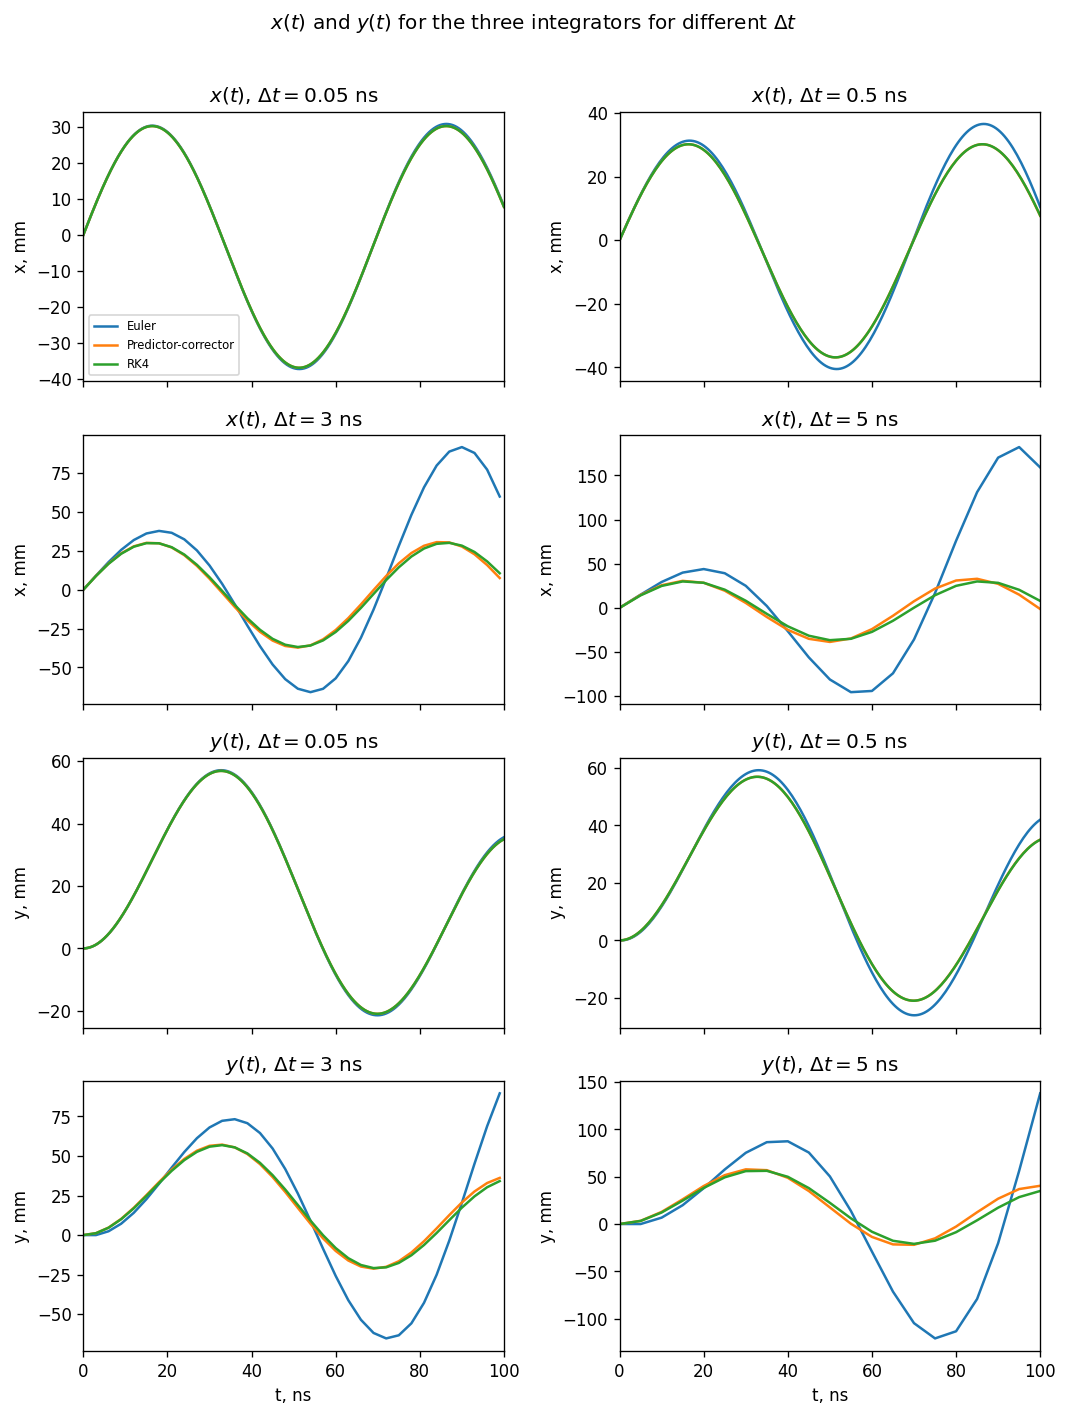

In [18]:
dt_values_ns = [0.05, 0.5, 3, 5]
methods = [("euler", "Euler"), ("pc", "Predictor-corrector"), ("rk4", "RK4")]
results_by_dt = {}
for dt_i in dt_values_ns:
    dt_s = dt_i * 1e-9
    results_by_dt[dt_i] = {
        "euler": unpack(euler(eom, r0, par, tmax, dt_s)),
        "pc": unpack(predictor_corrector(eom, r0, par, tmax, dt_s)),
        "rk4": unpack(runge_kutta_4(eom, r0, par, tmax, dt_s)),
    }
panels = [("x", dt_i) for dt_i in dt_values_ns] + [("y", dt_i) for dt_i in dt_values_ns]
fig, axes = plt.subplots(4, 2, figsize=(9, 12), sharex=True)
axes_flat = axes.flatten()
for ax, (comp, dt_i) in zip(axes_flat, panels):
    res = results_by_dt[dt_i]
    for key, label in methods:
        d = res[key]
        ax.plot(d["t"] * 1e9, d[comp] * 1e3, label=label)
    ax.set_title(rf"${comp}(t)$, $\Delta t={dt_i:g}$ ns")
    ax.set_xlim(0, 100)
    ax.set_ylabel(f"{comp}, mm")
for ax in axes_flat[-2:]:
    ax.set_xlabel("t, ns")
axes_flat[0].legend(loc="lower left", fontsize=7)
fig.suptitle(r"$x(t)$ and $y(t)$ for the three integrators for different $\Delta t$")
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig("fig_ex1_xy_vs_t_grid.png")
plt.show()

Plot the (x,y)-plane trajectory for the same step sizes, and print the RK4 radius estimate and the maximum momentum deviation.

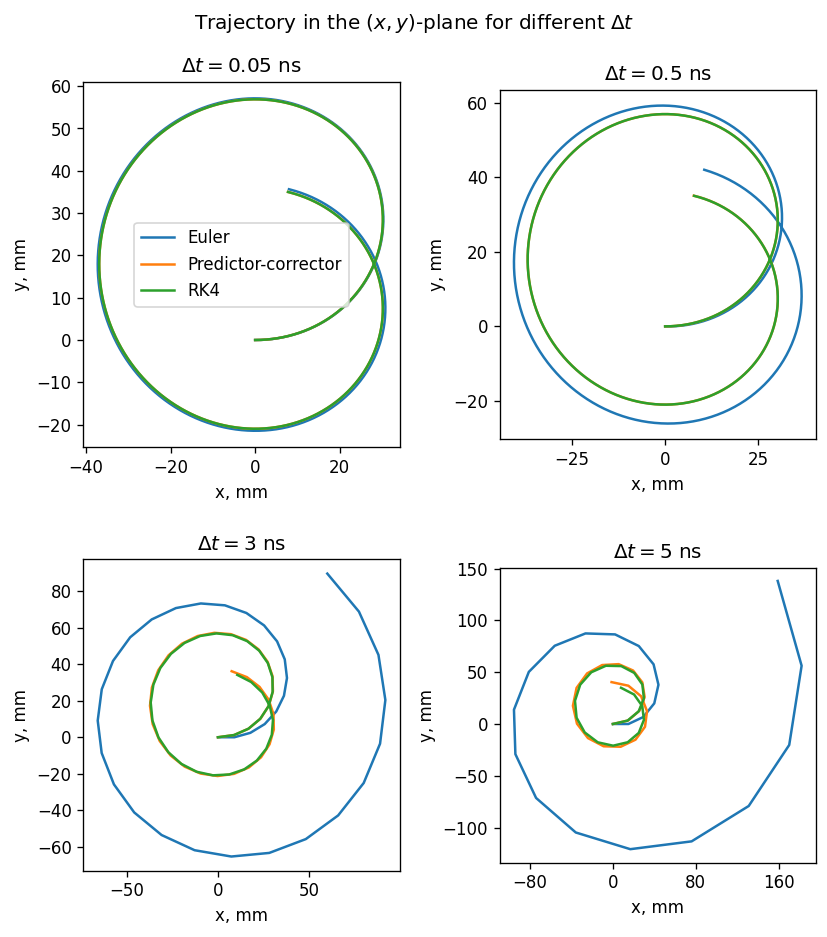

In [30]:
from matplotlib.ticker import MaxNLocator

dt_planes_ns = [0.05, 0.5, 3, 5]
fig, axes = plt.subplots(2, 2, figsize=(7, 8))
for i, (ax_i, dt_i) in enumerate(zip(axes.flat, dt_planes_ns)):
    res = results_by_dt[dt_i]
    for key, label in methods:
        d = res[key]
        ax_i.plot(d["x"] * 1e3, d["y"] * 1e3, label=label)
    ax_i.set_xlabel("x, mm")
    ax_i.set_ylabel("y, mm")
    ax_i.set_aspect("equal")
    ax_i.set_title(rf"$\Delta t={dt_i:g}$ ns")
    if i == 0:
        ax_i.legend()
    ax_i.xaxis.set_major_locator(MaxNLocator(nbins=4))
fig.suptitle(r"Trajectory in the $(x,y)$-plane for different $\Delta t$")
fig.tight_layout()
fig.savefig("fig_ex1_xy_plane_grid.png")
plt.show()

Plot the 3D (x,y,z) trajectory at the coarsest step size.

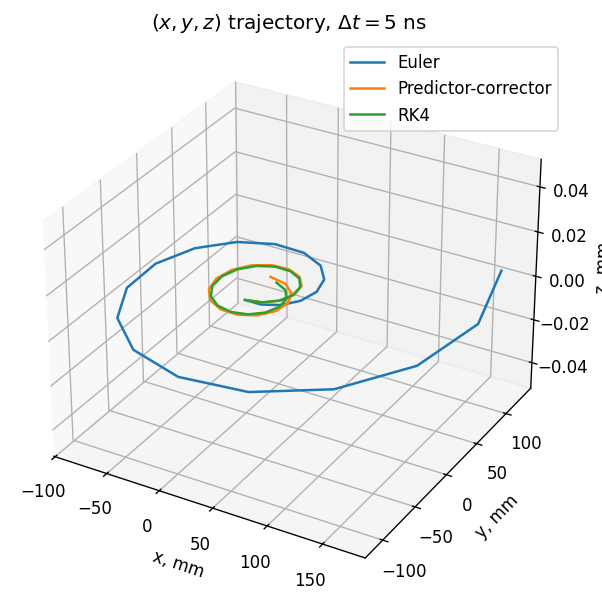

In [52]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(projection="3d")
for key, label in methods:
    d = results_by_dt[5][key]
    ax.plot(d["x"] * 1e3, d["y"] * 1e3, d["z"] * 1e3, label=label)
ax.set_xlabel("x, mm"); ax.set_ylabel("y, mm"); ax.set_zlabel("z, mm")
ax.set_title(r"$(x,y,z)$ trajectory, $\Delta t=5$ ns")
ax.margins(0)
ax.legend()
fig.subplots_adjust(left=0.05, right=0.85)
fig.savefig("fig_ex1_xyz_3d.png")
plt.show()

Plot the change in energy along the trajectory for each integrator.

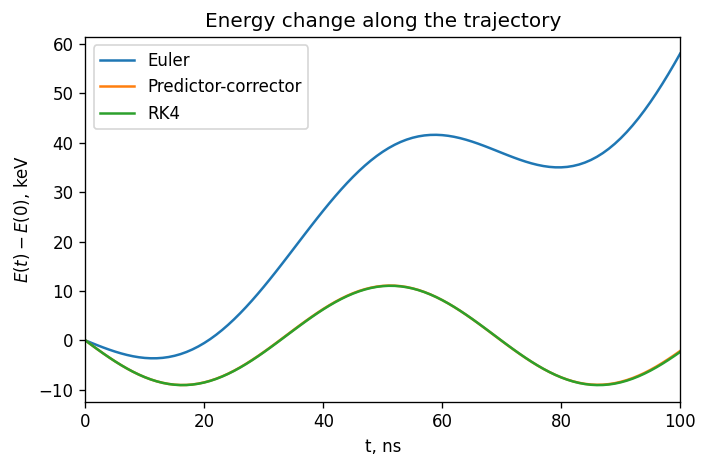

In [40]:
fig, ax = plt.subplots(figsize=(6, 4))
for d, label in [(d_euler, "Euler"), (d_pc, "Predictor-corrector"), (d_rk4, "RK4")]:
    E_check = np.sqrt(d["px"] ** 2 + d["py"] ** 2 + d["pz"] ** 2 + m ** 2)
    ax.plot(d["t"] * 1e9, (E_check - E_check[0]) * 1e6, label=label)
ax.set_xlabel("t, ns")
ax.set_ylabel(r"$E(t)-E(0)$, keV")
ax.set_title("Energy change along the trajectory")
ax.legend()
ax.set_xlim(0, 100)
fig.tight_layout()
fig.savefig("fig_ex1_energy.png")
plt.show()

Same trajectories as (x,y,t).

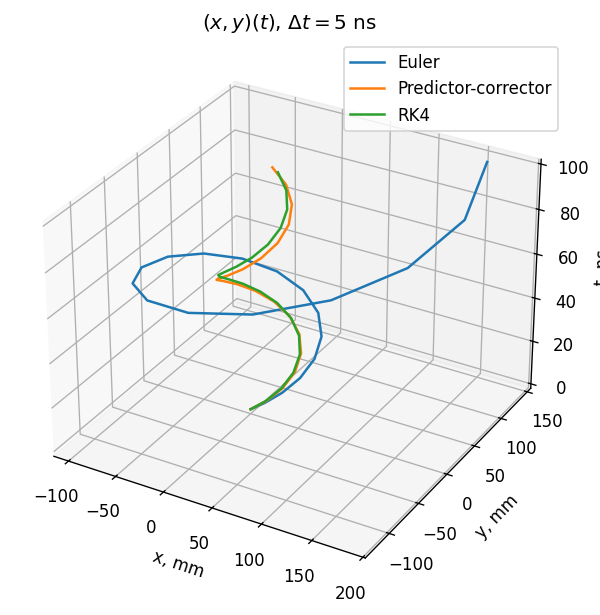

In [47]:
dt_spiral_ns = 5
method_color = {"euler": "tab:blue", "pc": "tab:orange", "rk4": "tab:green"}
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(projection="3d")
for key, label in methods:
    d = results_by_dt[dt_spiral_ns][key]
    ax.plot(d["x"] * 1e3, d["y"] * 1e3, d["t"] * 1e9, color=method_color[key], label=label)
ax.set_xlabel("x, mm"); ax.set_ylabel("y, mm")
ax.set_zlabel("t, ns")
ax.set_title(rf"$(x,y)(t)$, $\Delta t={dt_spiral_ns}$ ns")
ax.legend()
fig.subplots_adjust(left=0.05, right=0.85)
fig.savefig("fig_ex1_xyt_helix.png")
plt.show()

Repeat the propagation with the electric field switched off, and plot and print the resulting numerical momentum drift.

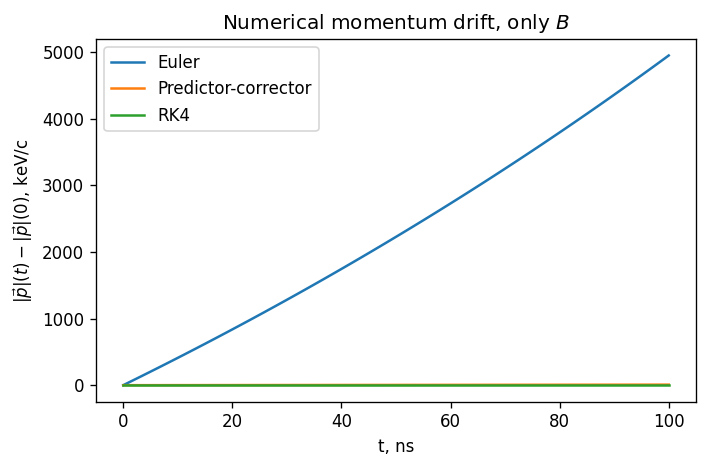

Max p deviation, only B
  Euler                 : 4951.9448 keV/c
  Predictor-corrector   : 8.1592 keV/c
  RK4                   : 0.0037 keV/c


In [45]:
par_B_only = (q, m, (0.0, 0.0, 0.0), B_field)
rs_rk4_B = runge_kutta_4(eom, r0, par_B_only, tmax, dt)
rs_euler_B = euler(eom, r0, par_B_only, tmax, dt)
rs_pc_B = predictor_corrector(eom, r0, par_B_only, tmax, dt)
d_rk4_B, d_euler_B, d_pc_B = unpack(rs_rk4_B), unpack(rs_euler_B), unpack(rs_pc_B)

fig, ax = plt.subplots(figsize=(6, 4))
for d, label in [(d_euler_B, "Euler"), (d_pc_B, "Predictor-corrector"), (d_rk4_B, "RK4")]:
    p = np.sqrt(d["px"] ** 2 + d["py"] ** 2 + d["pz"] ** 2)
    ax.plot(d["t"] * 1e9, (p - p[0]) * 1e6, label=label)
ax.set_xlabel("t, ns")
ax.set_ylabel(r"$|\vec p|(t)-|\vec p|(0)$, keV/c")
ax.set_title(r"Numerical momentum drift, only $B$")
ax.legend()
fig.tight_layout()
fig.savefig("fig_ex1_energy_Bonly.png")
plt.show()

print("Max p deviation, only B")
for d, label in [(d_euler_B, "Euler"), (d_pc_B, "Predictor-corrector"), (d_rk4_B, "RK4")]:
    p = np.sqrt(d["px"] ** 2 + d["py"] ** 2 + d["pz"] ** 2)
    print(f"  {label:22s}: {np.max(np.abs(p - p[0])) * 1e6:.4f} keV/c")

### Optional task: general electromagnetic field

Propagate a general (with all six components on) field with all three integrators and plot x(t),y(t),z(t) and the 3D trajectory.

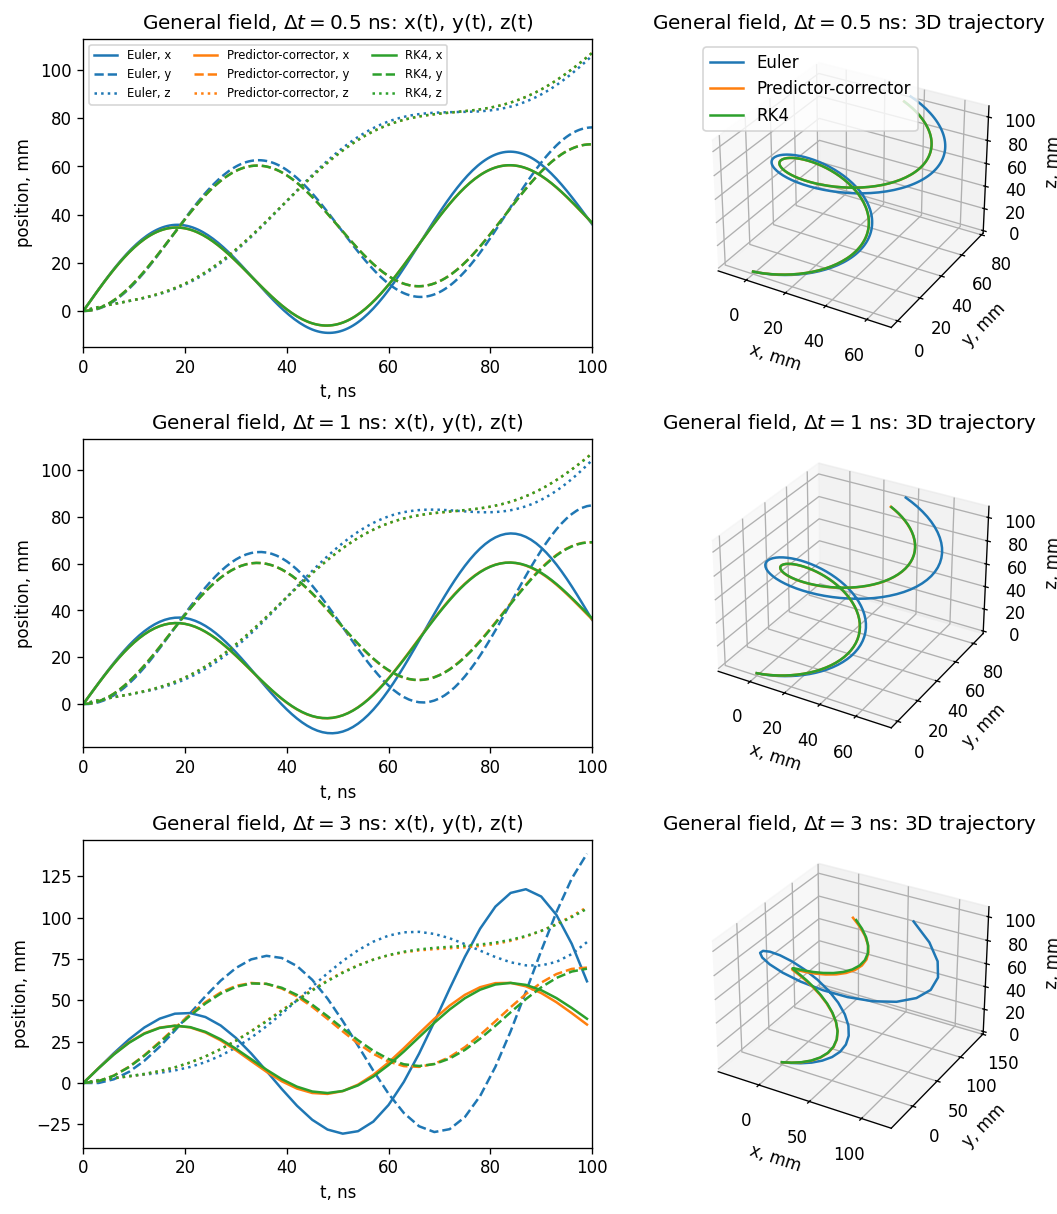

In [67]:
def plot_general_field_row(fig, row, dt_val, n_rows):
    rs_euler_g = euler(eom, r0_general, par_general, tmax, dt_val)
    rs_pc_g = predictor_corrector(eom, r0_general, par_general, tmax, dt_val)
    rs_rk4_g = runge_kutta_4(eom, r0_general, par_general, tmax, dt_val)
    d_euler_g, d_pc_g, d_rk4_g = unpack(rs_euler_g), unpack(rs_pc_g), unpack(rs_rk4_g)
    methods_g = [("euler", "Euler", d_euler_g), ("pc", "Predictor-corrector", d_pc_g), ("rk4", "RK4", d_rk4_g)]

    ax0 = fig.add_subplot(n_rows, 2, 2 * row + 1)
    for key, label, d in methods_g:
        ax0.plot(d["t"] * 1e9, d["x"] * 1e3, color=method_color[key], label=f"{label}, x")
        ax0.plot(d["t"] * 1e9, d["y"] * 1e3, "--", color=method_color[key], label=f"{label}, y")
        ax0.plot(d["t"] * 1e9, d["z"] * 1e3, ":", color=method_color[key], label=f"{label}, z")
    ax0.set_xlabel("t, ns"); ax0.set_ylabel("position, mm")
    ax0.set_xlim(0, 100)
    ax0.set_title(rf"General field, $\Delta t={dt_val*1e9:g}$ ns: x(t), y(t), z(t)")
    if row == 0:
        ax0.legend(fontsize=7, ncol=3)

    ax1 = fig.add_subplot(n_rows, 2, 2 * row + 2, projection="3d")
    for key, label, d in methods_g:
        ax1.plot(d["x"] * 1e3, d["y"] * 1e3, d["z"] * 1e3, color=method_color[key], label=label)
    ax1.set_xlabel("x, mm"); ax1.set_ylabel("y, mm"); ax1.set_zlabel("z, mm")
    ax1.set_title(rf"General field, $\Delta t={dt_val*1e9:g}$ ns: 3D trajectory")
    if row == 0:
        ax1.legend()


Ex_g, Ey_g, Ez_g = 1.0e5, 0.5e5, 0.0
Bx_g, By_g, Bz_g = 0.3, 0.2, 1.0
par_general = (q, m, (Ex_g, Ey_g, Ez_g), (Bx_g, By_g, Bz_g))
r0_general = np.array([t0, x0, y0, z0, E0, px0, py0, 0.2 * px0])

dt_list_ns = [0.5, 1, 3]
fig = plt.figure(figsize=(10, 4 * len(dt_list_ns)))
for row, dt_ns_val in enumerate(dt_list_ns):
    plot_general_field_row(fig, row, dt_ns_val * 1e-9, len(dt_list_ns))

fig.subplots_adjust(left=0.1, right=0.95, wspace=0.005, hspace=0.3)
fig.savefig("fig_ex1_general_3d.png")
plt.show()

## Exercise 2: MC simulation of the resonance mass

Load the measured resonance mass spectrum from resonance.dat. Extract the bin positions, contents and width from the loaded data. Set the default number of Monte-Carlo samples.

In [70]:
file_path = "resonance.dat"
data = pd.read_csv(file_path, sep="\t")

In [71]:
bin_positions = data["x"].to_numpy(dtype=float)
bin_contents = data["y"].to_numpy(dtype=float)
n_bins = len(bin_positions)
bin_width = bin_positions[1] - bin_positions[0]

In [72]:
num_samples = 10000

Plot the measured mass histogram.

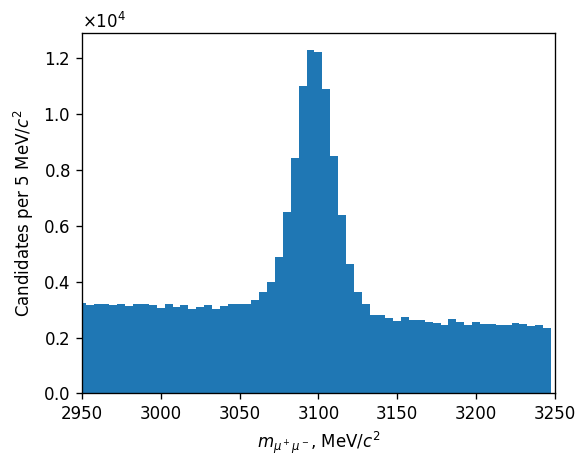

In [73]:
from matplotlib.ticker import ScalarFormatter

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(bin_positions, bin_contents, width=bin_width, align="center")

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(formatter)

ax.set_xlim(2950, 3250)
ax.set_xlabel(r"$m_{\mu^+\mu^-}$, $\text{MeV}/c^2$")
ax.set_ylabel(r"Candidates per 5 $\text{MeV}/c^2$")
plt.tight_layout()
plt.savefig("fig_ex2_pdf.png")
plt.show()

Compute and plot the cumulative distribution function of the histogram.

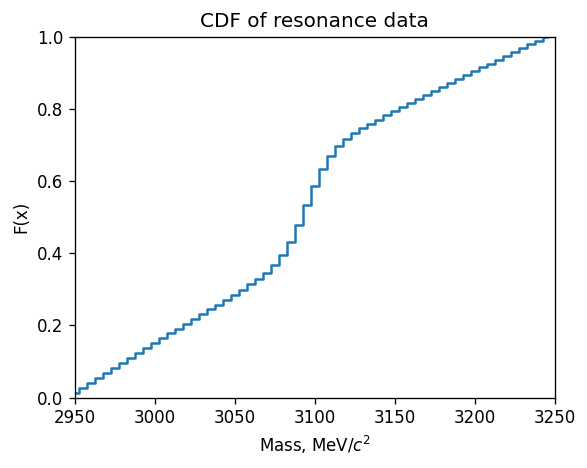

In [149]:
cdf_values = np.cumsum(bin_contents) / np.sum(bin_contents)

plt.figure(figsize=(5, 4))
plt.step(bin_positions, cdf_values, where="mid")
plt.xlim(2950, 3250)
plt.ylim(0, 1)
plt.xlabel(r"Mass, $\text{MeV}/c^2$")
plt.ylabel("F(x)")
plt.title("CDF of resonance data")
plt.tight_layout()
plt.savefig("fig_ex2_cdf.png")
plt.show()

Define the acceptance-rejection sampler, run it and plot the resulting histogram.

In [77]:
def hit_and_miss_sampling(bin_contents, bin_positions, num_samples):
    max_bin_content = np.max(bin_contents)
    accepted_samples_hm = np.zeros(len(bin_positions))

    for _ in range(num_samples):
        random_x = np.random.randint(0, len(bin_positions))
        random_y = np.random.rand() * max_bin_content

        if random_y <= bin_contents[random_x]:
            accepted_samples_hm[random_x] += 1

    return accepted_samples_hm

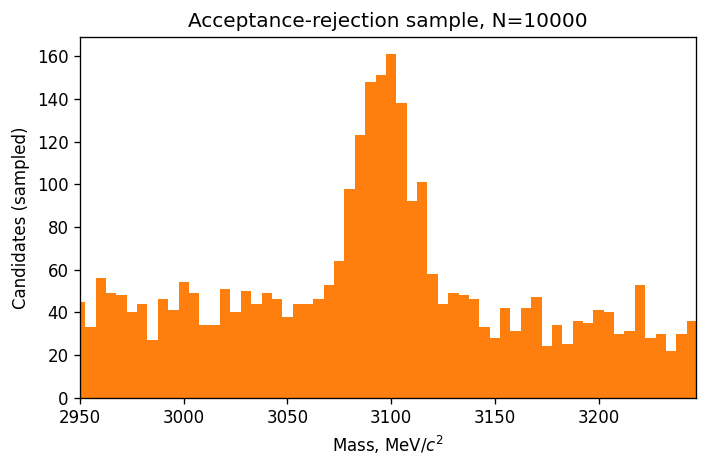

In [89]:
accepted_samples_hm = hit_and_miss_sampling(bin_contents, bin_positions, num_samples)

plt.figure(figsize=(6, 4))
plt.bar(bin_positions, accepted_samples_hm, width=bin_width, align="center", color="tab:orange")
plt.xlim(2950, 3247)
plt.xlabel(r"Mass, $\text{MeV}/c^2$")
plt.ylabel("Candidates (sampled)")
plt.title(f"Acceptance-rejection sample, N={num_samples}")
plt.tight_layout()
plt.savefig("fig_ex2_hm_hist.png")
plt.show()

Define the inverse-CDF sampler, run it and plot histogram.

In [91]:
def inverse_cdf_sampling(cdf_values, bin_positions, num_samples):
    """Inverse-CDF sampling."""
    accepted_samples_inv = np.zeros(len(bin_positions))

    for _ in range(num_samples):
        u = np.random.rand()
        k = np.searchsorted(cdf_values, u)
        accepted_samples_inv[k] += 1

    return accepted_samples_inv

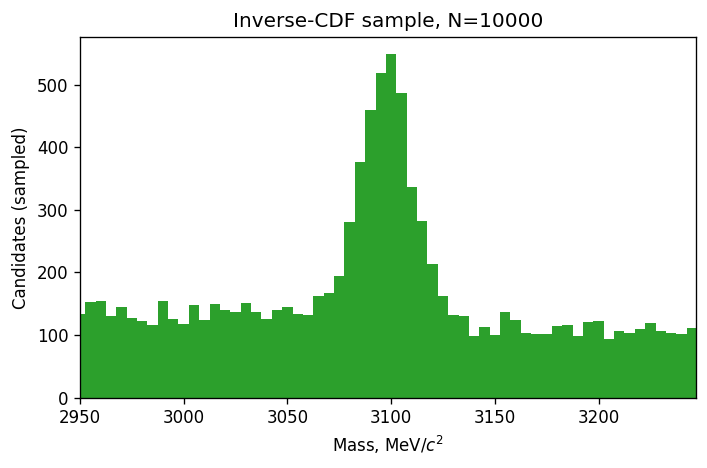

In [92]:
accepted_samples_inv = inverse_cdf_sampling(cdf_values, bin_positions, num_samples)

plt.figure(figsize=(6, 4))
plt.bar(bin_positions, accepted_samples_inv, width=bin_width, align="center",
        color="tab:green")
plt.xlim(2950, 3247)
plt.xlabel(r"Mass, $\text{MeV}/c^2$")
plt.ylabel("Candidates (sampled)")
plt.title(f"Inverse-CDF sample, N={num_samples}")
plt.tight_layout()
plt.savefig("fig_ex2_inv_hist.png")
plt.show()

Define shortcut function that draws a fixed number of masses with the inverse-CDF method. Then define the chi-squared comparison between two area-normalised histograms.

In [93]:
def sample_values(cdf_values, bin_positions, events):
    values = []
    for _ in range(events):
        u = np.random.rand()
        k = np.searchsorted(cdf_values, u)
        values.append(bin_positions[k])
    return values

In [94]:
def chi2(sample, data):

    sample = np.asarray(sample, dtype=float)
    data = np.asarray(data, dtype=float)
    if len(sample) != len(data):
        raise ValueError("diff number of bins")

    sample_norm = sample / np.sum(sample)
    data_norm = data / np.sum(data)

    chi2_values = (data_norm - sample_norm) ** 2
    return np.sum(chi2_values)

Compute chi-squared for the acceptance-rejection sample. Then compute chi-squared for the inverse-CDF sample.

In [95]:
chi2_hm = chi2(accepted_samples_hm, bin_contents)
chi2_hm

np.float64(0.0003991655889294626)

In [96]:
chi2_inv = chi2(accepted_samples_inv, bin_contents)
chi2_inv

np.float64(8.258040814297101e-05)

Define the sampling efficiency and conmpute in the next two windows for both sampling methods.

In [97]:
def efficiency(sample, num_samples):
    return np.sum(sample) / num_samples

In [98]:
eff_hm = efficiency(accepted_samples_hm, num_samples)
eff_hm

np.float64(0.3144)

In [99]:
eff_inv = efficiency(accepted_samples_inv, num_samples)
eff_inv

np.float64(1.0)

Repeat both samplers for several sample sizes and collect efficiency/chi-squared into a table.

In [100]:
rows = []
for N in (10, 1000, 10000):
    s_hm = hit_and_miss_sampling(bin_contents, bin_positions, N)
    s_inv = inverse_cdf_sampling(cdf_values, bin_positions, N)
    rows.append({
        "N_sampled": N,
        "eff_hm": efficiency(s_hm, N),
        "chi2_hm": chi2(s_hm, bin_contents),
        "eff_inv": efficiency(s_inv, N),
        "chi2_inv": chi2(s_inv, bin_contents),
    })
comparison_table = pd.DataFrame(rows)
comparison_table.to_csv("table_ex2_comparison.csv", index=False)
comparison_table

,N_sampled,eff_hm,chi2_hm,eff_inv,chi2_inv
0,10,0.5000,0.196145,1.0,0.073149
1,1000,0.2880,0.003913,1.0,0.000958
2,10000,0.3178,0.000326,1.0,0.000090


Estimate the resonance mass and width from the histogram peak.

In [101]:
peak_idx = np.argmax(bin_contents)
m_est = bin_positions[peak_idx]

half_max = bin_contents[peak_idx] / 2
above = bin_positions[bin_contents >= half_max]
gamma_est = above.max() - above.min()

print(f"Estimated resonance mass  m  = {m_est:.1f} MeV/c^2")
print(f"Estimated resonance width Gamma = {gamma_est:.1f} MeV/c^2")

Estimated resonance mass  m  = 3095.0 MeV/c^2
Estimated resonance width Gamma = 35.0 MeV/c^2


### Optional task: fit with the Breit-Wigner function and continuous-PDF sampling

Fit the spectrum with a Breit-Wigner peak plus a constant background.

Fitted mass:      m     = 3097.23 +/- 0.35 MeV/c^2
Fitted width:     Gamma = 25.39 +/- 1.16 MeV/c^2
Fitted background:B0    = 2528.6 +/- 71.2 counts
Fitted amplitude: sigma0= 10592.9 +/- 296.1 counts


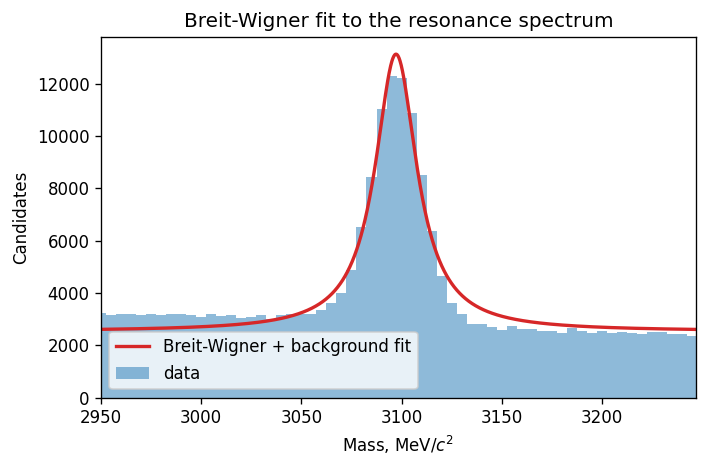

In [106]:
from scipy.optimize import curve_fit

def breit_wigner_bg(x, B0, sigma0, m_fit, Gamma):
    return B0 + sigma0 * (Gamma**2 / 4) / ((x - m_fit) ** 2 + Gamma**2 / 4)

p0 = [bin_contents.min(), bin_contents.max() - bin_contents.min(), m_est, gamma_est]
popt, pcov = curve_fit(breit_wigner_bg, bin_positions, bin_contents, p0=p0)
B0_fit, sigma0_fit, m_fit, Gamma_fit = popt
perr = np.sqrt(np.diag(pcov))

print(f"Fitted mass:      m     = {m_fit:.2f} +/- {perr[2]:.2f} MeV/c^2")
print(f"Fitted width:     Gamma = {Gamma_fit:.2f} +/- {perr[3]:.2f} MeV/c^2")
print(f"Fitted background:B0    = {B0_fit:.1f} +/- {perr[0]:.1f} counts")
print(f"Fitted amplitude: sigma0= {sigma0_fit:.1f} +/- {perr[1]:.1f} counts")

x_fine = np.linspace(bin_positions.min() - bin_width / 2,
                      bin_positions.max() + bin_width / 2, 2000)
f_fit = breit_wigner_bg(x_fine, *popt)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(bin_positions, bin_contents, width=bin_width, alpha=0.5, label="data")
ax.plot(x_fine, f_fit, color="tab:red", lw=2, label="Breit-Wigner + background fit")
ax.set_xlabel(r"Mass, $\text{MeV}/c^2$"); ax.set_ylabel("Candidates")
ax.set_title("Breit-Wigner fit to the resonance spectrum")
ax.set_xlim(2950, 3247)
ax.legend()
fig.tight_layout()
fig.savefig("fig_ex2_bwfit.png")
plt.show()

With the continuous fitted PDF in hand, both sampling methods can be
repeated without relying on the binned histogram. For the inverse-CDF
method, the CDF is built on a fine grid and inverted with linear
interpolation, since $f(x)$ has no simple closed-form inverse once the
background term is included.

Define acception-rejection and inverse-CDF samplers that work on a continuous PDF instead of a histogram.

In [103]:
def hit_and_miss_sampling_continuous(f, a, b, f_max, num_samples):
    accepted = []
    n_retained = 0
    for _ in range(num_samples):
        x_trial = a + np.random.rand() * (b - a)
        y_trial = np.random.rand() * f_max
        if y_trial <= f(x_trial):
            accepted.append(x_trial)
            n_retained += 1
    return np.array(accepted), n_retained / num_samples

def inverse_cdf_sampling_continuous(f, a, b, num_samples, n_grid=2000):
    x_grid = np.linspace(a, b, n_grid)
    pdf_grid = f(x_grid)
    cdf_grid = np.concatenate(([0.0], np.cumsum((pdf_grid[1:] + pdf_grid[:-1]) / 2 * np.diff(x_grid))))
    cdf_grid /= cdf_grid[-1]
    u = np.random.rand(num_samples)
    return np.interp(u, cdf_grid, x_grid)

Sample from the fitted continuous PDF with both methods and compare to the histogram-based results.

Continuous-PDF acceptance-rejection:  eff = 0.2892, chi2 = 0.00056
Continuous-PDF inverse-CDF:   eff = 1.0000, chi2 = 0.00032
(cf.\ histogram-based, N=10000: eff_hm=0.3178, chi2_hm=0.00033, chi2_inv=0.00009)


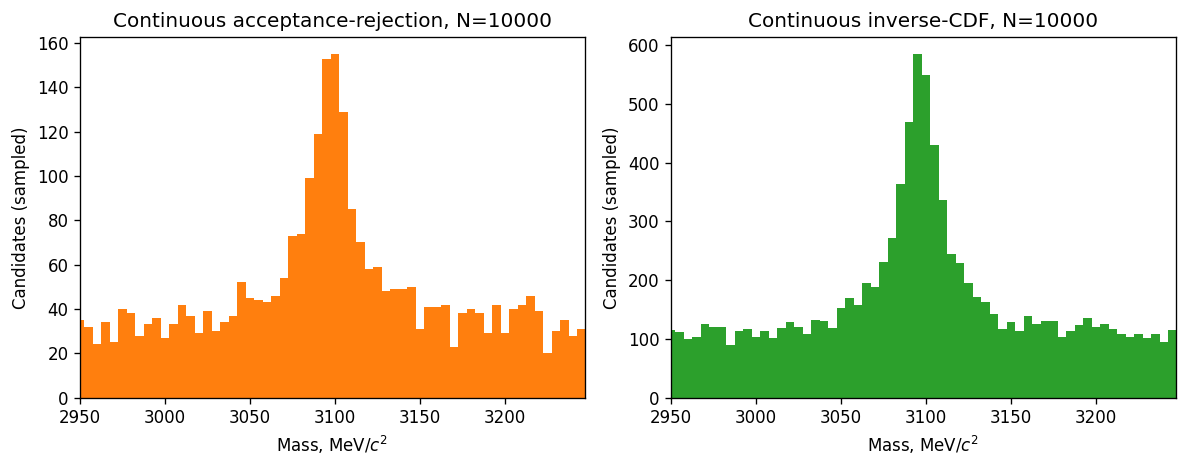

,method,efficiency,chi2
0,acceptance-rejection (continuous fit),0.2892,0.000559
1,inverse-CDF (continuous fit),1.0000,0.000318


In [108]:
a_fit, b_fit = bin_positions.min() - bin_width / 2, bin_positions.max() + bin_width / 2
f_max_fit = np.max(breit_wigner_bg(x_fine, *popt))

samples_hm_cont, eff_hm_cont = hit_and_miss_sampling_continuous(
    lambda x: breit_wigner_bg(x, *popt), a_fit, b_fit, f_max_fit, num_samples)
samples_inv_cont = inverse_cdf_sampling_continuous(
    lambda x: breit_wigner_bg(x, *popt), a_fit, b_fit, num_samples)

hm_binned_cont, _ = np.histogram(samples_hm_cont, bins=len(bin_positions), range=(a_fit, b_fit))
inv_binned_cont, _ = np.histogram(samples_inv_cont, bins=len(bin_positions), range=(a_fit, b_fit))

chi2_hm_cont = chi2(hm_binned_cont, bin_contents)
chi2_inv_cont = chi2(inv_binned_cont, bin_contents)
eff_inv_cont = 1.0 

print(f"Continuous-PDF acceptance-rejection:  eff = {eff_hm_cont:.4f}, chi2 = {chi2_hm_cont:.5f}")
print(f"Continuous-PDF inverse-CDF:   eff = {eff_inv_cont:.4f}, chi2 = {chi2_inv_cont:.5f}")
print(f"(cf.\\ histogram-based, N=10000: eff_hm={comparison_table.iloc[-1]['eff_hm']:.4f}, "
      f"chi2_hm={comparison_table.iloc[-1]['chi2_hm']:.5f}, "
      f"chi2_inv={comparison_table.iloc[-1]['chi2_inv']:.5f})")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(bin_positions, hm_binned_cont, width=bin_width, color="tab:orange")
ax[0].set_title(f"Continuous acceptance-rejection, N={num_samples}")
ax[0].set_xlim(2950,3247)
ax[0].set_xlabel(r"Mass, $\text{MeV}/c^2$"); ax[0].set_ylabel("Candidates (sampled)")
ax[1].bar(bin_positions, inv_binned_cont, width=bin_width, color="tab:green")
ax[1].set_title(f"Continuous inverse-CDF, N={num_samples}")
ax[1].set_xlim(2950,3247)
ax[1].set_xlabel(r"Mass, $\text{MeV}/c^2$"); ax[1].set_ylabel("Candidates (sampled)")
fig.tight_layout()
fig.savefig("fig_ex2_continuous_hist.png")
plt.show()

continuous_comparison = pd.DataFrame({
    "method": ["acceptance-rejection (continuous fit)", "inverse-CDF (continuous fit)"],
    "efficiency": [eff_hm_cont, eff_inv_cont],
    "chi2": [chi2_hm_cont, chi2_inv_cont],
})
continuous_comparison.to_csv("table_ex2_continuous.csv", index=False)
continuous_comparison

## Exercise 3: Simulation of $J/\psi\to\mu^+\mu^-$ decay and reconstruction of muon momenta

Define a helper that builds a 4-momentum from a mass, a momentum magnitude and direction angles.

In [128]:
def four_momentum(m, p, cos_theta, phi):
    theta = np.arccos(cos_theta)

    px = p * np.sin(theta) * np.cos(phi)
    py = p * np.sin(theta) * np.sin(phi)
    pz = p * np.cos(theta)
    E = np.sqrt(p**2 + m**2)   # natural units, c = 1

    return E, px, py, pz

Define a helper that extracts the polar/azimuthal angles from a momentum vector.

In [129]:
def angles(px, py, pz):
    p = np.sqrt(px**2 + py**2 + pz**2)
    cos_theta = pz / p
    phi = np.arctan2(py, px)
    return cos_theta, phi

Define the function that reconstructs momentum from two points on a circular track.

In [130]:
def momentum_from_circle(point1, point2, q, B):
    t1, x1, y1, z1, E1, px1, py1, pz1 = point1
    t2, x2, y2, z2, E2, px2, py2, pz2 = point2

    r1 = np.array([x1, y1, z1])
    r2 = np.array([x2, y2, z2])
    p1 = np.array([px1, py1, pz1])
    p2 = np.array([px2, py2, pz2])

    B = np.array(B, dtype=float)
    B_e = B / np.linalg.norm(B)

    p1_par = np.dot(p1, B_e) * B_e
    p2_par = np.dot(p2, B_e) * B_e
    p1_perp = p1 - p1_par
    p2_perp = p2 - p2_par

    d = r2 - r1
    d_perp = d - np.dot(d, B_e) * B_e

    cos_theta = np.dot(p1_perp, p2_perp) / (np.linalg.norm(p1_perp) * np.linalg.norm(p2_perp))

    R = np.linalg.norm(d_perp) / (2 * np.sqrt(np.abs(1 - np.abs(cos_theta)) / 2))

    qBR_SI = q * np.linalg.norm(B) * R
    qBR_GeVc = qBR_SI * c / GeV_to_J

    p = np.sqrt(np.linalg.norm(p2_par) ** 2 + qBR_GeVc ** 2)

    return R, p

Define a simpler radius estimate from two points and their momentum directions.

In [131]:
def radius_of_circle(point1, point2):
    t1, x1, y1, z1, E1, px1, py1, pz1 = point1
    t2, x2, y2, z2, E2, px2, py2, pz2 = point2

    d = np.sqrt((x2 - x1)**2 + (y2 - y1)**2 + (z2 - z1)**2)

    p1 = np.array([px1, py1, pz1])
    p2 = np.array([px2, py2, pz2])

    cos_theta = np.dot(p1, p2) / (np.linalg.norm(p1) * np.linalg.norm(p2))

    R = d / (2 * np.abs(cos_theta))
    return R

Define the p = qBR relation, converted to GeV/c and set the muon mass.

In [132]:
def momentum_from_radius(R, q, B):
    B_mag = np.linalg.norm(np.array(B, dtype=float))
    p_SI = q * B_mag * R
    p_GeVc = p_SI * c / GeV_to_J
    return p_GeVc

Set the muon mass and define the J/psi decay into two back-to-back muons with random direction and charge.

In [133]:
m_mu = 0.1057   # GeV/c^2

In [134]:
def jpsi_to_mumu(m_jpsi):
    E_mu = m_jpsi / 2
    p_mu = np.sqrt(E_mu**2 - m_mu**2)
    cos_theta = np.random.uniform(-1.0, 1.0)
    theta = np.arccos(cos_theta)
    phi = np.random.uniform(-np.pi, np.pi)

    px = p_mu * np.sin(theta) * np.cos(phi)
    py = p_mu * np.sin(theta) * np.sin(phi)
    pz = p_mu * np.cos(theta)

    p1 = np.array([E_mu, px, py, pz])
    p2 = np.array([E_mu, -px, -py, -pz])

    charge_muon_1 = 1 if np.random.rand() < 0.5 else -1
    charge_muon_2 = -charge_muon_1

    if charge_muon_1 == -1:
        return p1, p2
    else:
        return p2, p1

Define the reconstructed J/psi mass from two muon 4-momenta.

In [135]:
def jpsi_from_mumu(p1, p2):
    E = p1[0] + p2[0]
    px = p1[1] + p2[1]
    py = p1[2] + p2[2]
    pz = p1[3] + p2[3]

    M_mumu = np.sqrt(E**2 - (px**2 + py**2 + pz**2))
    return M_mumu

Simulate the decay and track reconstruction for 200 events, and print the consistency and momentum-error checks.

In [136]:
np.random.seed(42)

Nevents = 200
tmu0, xmu0, ymu0, zmu0 = 0.0, 0.0, 0.0, 0.0 # s, m, m, m
tmumax, dtmu = 1.0e-9, 1.0e-9 # s
E_exp = (0.0, 0.0, 0.0) # V/m
B_exp = (0.0, 1.0, 0.0) # T
par_minus = (-e, m_mu, E_exp, B_exp)
par_plus = (e, m_mu, E_exp, B_exp)

M_mumu = np.array(sample_values(cdf_values, bin_positions, Nevents)) / 1000.0

M_mumu_sim = []
pmu_minus, pmu_plus = [], []
pmu_minus_sim, pmu_plus_sim = [], []
dp_over_p_minus, dp_over_p_plus = [], []

for M in M_mumu:
    p1, p2 = jpsi_to_mumu(M)
    pmu_minus.append(p1)
    pmu_plus.append(p2)

    r0_minus = np.array([tmu0, xmu0, ymu0, zmu0, p1[0], p1[1], p1[2], p1[3]])
    r0_plus = np.array([tmu0, xmu0, ymu0, zmu0, p2[0], p2[1], p2[2], p2[3]])

    traj_minus = runge_kutta_4(eom, r0_minus, par_minus, tmumax, dtmu)
    traj_plus = runge_kutta_4(eom, r0_plus, par_plus, tmumax, dtmu)

    R_minus, p_reco_minus = momentum_from_circle(traj_minus[0], traj_minus[1], par_minus[0], B_exp)
    R_plus, p_reco_plus = momentum_from_circle(traj_plus[0], traj_plus[1], par_plus[0], B_exp)

    p_true_minus = np.linalg.norm(p1[1:])
    p_true_plus = np.linalg.norm(p2[1:])

    pmu_minus_sim.append(p_reco_minus)
    pmu_plus_sim.append(p_reco_plus)
    dp_over_p_minus.append(abs(p_true_minus - p_reco_minus) / p_true_minus)
    dp_over_p_plus.append(abs(p_true_plus - p_reco_plus) / p_true_plus)

    M_mumu_sim.append(jpsi_from_mumu(p1, p2))

M_mumu_sim = np.array(M_mumu_sim)
dp_over_p_minus = np.array(dp_over_p_minus)
dp_over_p_plus = np.array(dp_over_p_plus)

print(f"Max |M_reconstructed - M_generated| = "
      f"{np.max(np.abs(M_mumu_sim - M_mumu)):.2e} GeV/c^2  "
      "(consistency check of jpsi_to_mumu / jpsi_from_mumu)")
print(f"Mean relative momentum error, mu-: {np.mean(dp_over_p_minus):.4f}")
print(f"Mean relative momentum error, mu+: {np.mean(dp_over_p_plus):.4f}")

Max |M_reconstructed - M_generated| = 0.00e+00 GeV/c^2  (consistency check of jpsi_to_mumu / jpsi_from_mumu)
Mean relative momentum error, mu-: 0.0008
Mean relative momentum error, mu+: 0.0008


Plot the momentum-error distribution and the generated vs. recomputed J/psi mass and collect the mean momentum error into a summary table.

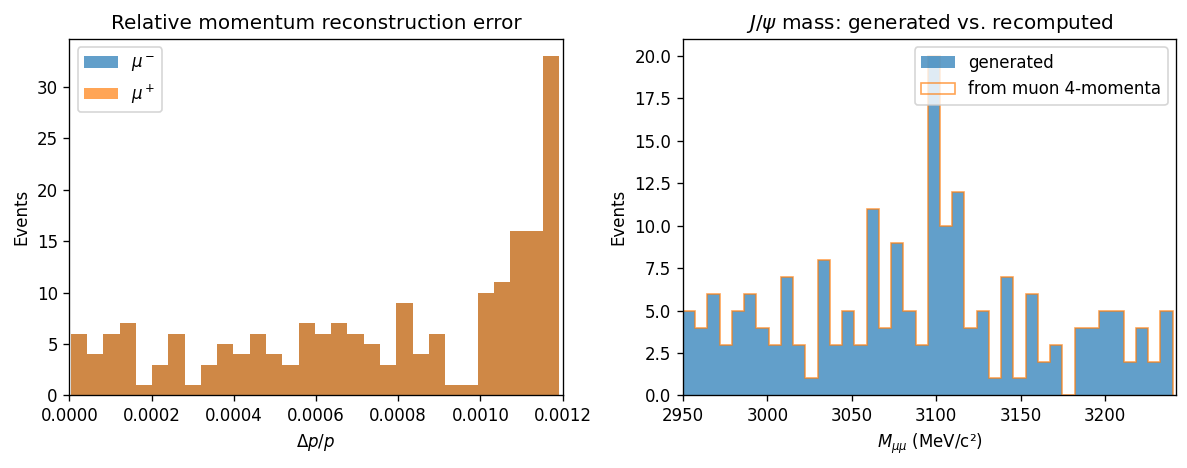

In [146]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(dp_over_p_minus, bins=30, alpha=0.7, label=r"$\mu^-$")
ax[0].hist(dp_over_p_plus, bins=30, alpha=0.7, label=r"$\mu^+$")
ax[0].set_xlim(0, 0.0012)
ax[0].set_xlabel(r"$\Delta p / p$")
ax[0].set_ylabel("Events")
ax[0].set_title("Relative momentum reconstruction error")
ax[0].legend()

ax[1].hist(M_mumu * 1000, bins=40, alpha=0.7, label="generated")
ax[1].hist(M_mumu_sim * 1000, bins=40, alpha=0.7, histtype="step", lw=2, label="from muon 4-momenta")
ax[1].set_xlabel(r"$M_{\mu\mu}$ (MeV/c²)")
ax[1].set_xlim(2950, 3242)
ax[1].set_ylabel("Events")
ax[1].set_title(r"$J/\psi$ mass: generated vs. recomputed")
ax[1].legend()

fig.tight_layout()
fig.savefig("fig_ex3_summary.png")
plt.show()

In [121]:
summary_ex3 = pd.DataFrame({
    "quantity": ["mean Delta p/p (mu-)", "mean Delta p/p (mu+)",
                 "median Delta p/p (mu-)", "median Delta p/p (mu+)"],
    "value": [np.mean(dp_over_p_minus), np.mean(dp_over_p_plus),
              np.median(dp_over_p_minus), np.median(dp_over_p_plus)],
})
summary_ex3.to_csv("table_ex3_summary.csv", index=False)
summary_ex3

,quantity,value
0,mean Delta p/p (mu-),0.000762
1,mean Delta p/p (mu+),0.000762
2,median Delta p/p (mu-),0.000831
3,median Delta p/p (mu+),0.000831
